# The KL weight, and how a VAE loses its code\nOne model, three values of $\\beta$ in\n$-\\mathbb{E}_{q_\\phi}[\\log p_\\theta(x\\mid z)] + \\beta\\, D_{\\mathrm{KL}}(q_\\phi(z\\mid x)\\,\\|\\,p(z))$.\n\nDigit labels are used only to colour the code plot, never to train.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/17-autoencoders-vaes-vqvae/'
for _name in ['SklearnDigits.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch import nn

torch.manual_seed(26520); np.random.seed(26520)
frame = pd.read_csv('SklearnDigits.csv')
pixels, labels = frame.drop(columns='target').to_numpy(float), frame['target'].to_numpy(int)

X = torch.tensor(pixels / 16.0, dtype=torch.float32)
n, d = X.shape
print(f'{n} images, {d} pixels each, values in [{X.min():.0f}, {X.max():.0f}]')

1797 images, 64 pixels each, values in [0, 1]


## The model\nThe encoder returns a mean and a log variance; the code is drawn with the reparameterization trick so the gradient reaches $\\phi$. The KL is kept **per coordinate**, which is the quantity that reveals a collapse.

In [2]:
class VAE(nn.Module):
    """Gaussian encoder, Bernoulli decoder. Nothing here depends on beta."""
    def __init__(self, latent=2, hidden=128):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(d, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU())
        self.mean = nn.Linear(hidden, latent)
        self.log_variance = nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, d))

    def encode(self, x):
        h = self.body(x)
        return self.mean(h), self.log_variance(h)

    def forward(self, x):
        mean, log_variance = self.encode(x)
        code = mean + torch.exp(0.5 * log_variance) * torch.randn_like(mean)   # reparameterization
        return self.decoder(code), mean, log_variance


def kl_per_coordinate(mean, log_variance):
    """-1/2 (1 + log s^2 - mu^2 - s^2), averaged over images, kept per coordinate."""
    return (-0.5 * (1 + log_variance - mean ** 2 - log_variance.exp())).mean(dim=0)

## Train at three values of $\\beta$

In [3]:
def train(beta, latent=2, epochs=250, seed=26531, lr=2e-3, batch=128):
    torch.manual_seed(seed)
    model = VAE(latent=latent)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    generator = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        order = torch.randperm(n, generator=generator)
        for start in range(0, n, batch):
            xb = X[order[start:start + batch]]
            logits, mean, log_variance = model(xb)
            reconstruction = nn.functional.binary_cross_entropy_with_logits(logits, xb, reduction='sum') / len(xb)
            divergence = kl_per_coordinate(mean, log_variance).sum()
            optimizer.zero_grad(); (reconstruction + beta * divergence).backward(); optimizer.step()
    model.eval()
    with torch.no_grad():
        logits, mean, log_variance = model(X)
        report = dict(
            reconstruction=nn.functional.binary_cross_entropy_with_logits(logits, X, reduction='sum').item() / n,
            kl=kl_per_coordinate(mean, log_variance).numpy(),
            codes=mean.numpy())
    return model, report


betas = [0.2, 1.0, 6.0]
fits = {}
for beta in betas:
    fits[beta] = train(beta)
    model, report = fits[beta]
    print(f'beta={beta:<4} reconstruction {report["reconstruction"]:6.1f} nats   '
          f'KL per coordinate {np.round(report["kl"], 3)}')

beta=0.2  reconstruction   18.8 nats   KL per coordinate [2.746 2.704]


beta=1.0  reconstruction   20.8 nats   KL per coordinate [1.573 1.485]


beta=6.0  reconstruction   27.1 nats   KL per coordinate [0. 0.]


## What the decoder produces

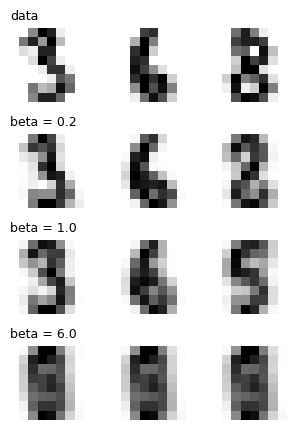

In [4]:
def decode(model, index):
    with torch.no_grad():
        logits, _, _ = model(X[index])
        return torch.sigmoid(logits).numpy()

index = [int(np.where(labels == digit)[0][0]) for digit in (3, 6, 8)]
fig, axes = plt.subplots(len(betas) + 1, len(index), figsize=(3.2, 4.4))
for column, row in enumerate(index):
    axes[0, column].imshow(X[row].numpy().reshape(8, 8), cmap='gray_r'); axes[0, column].axis('off')
axes[0, 0].set_title('data', loc='left', fontsize=9)
for panel, beta in enumerate(betas, start=1):
    rebuilt = decode(fits[beta][0], index)
    for column in range(len(index)):
        axes[panel, column].imshow(rebuilt[column].reshape(8, 8), cmap='gray_r'); axes[panel, column].axis('off')
    axes[panel, 0].set_title(f'beta = {beta}', loc='left', fontsize=9)
plt.tight_layout(); plt.show()

## Where the information went

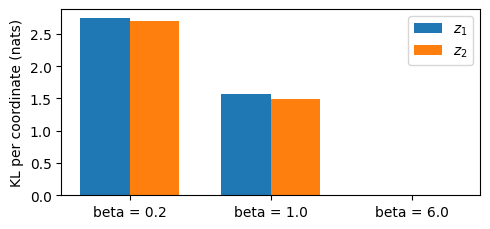

A coordinate with KL near zero carries no information about the image.


In [5]:
fig, ax = plt.subplots(figsize=(5, 2.4))
width = 0.35
for offset, coordinate in zip((-width / 2, width / 2), range(2)):
    ax.bar(np.arange(len(betas)) + offset, [fits[b][1]['kl'][coordinate] for b in betas],
           width=width, label=f'$z_{coordinate + 1}$')
ax.set(xticks=range(len(betas)), xticklabels=[f'beta = {b}' for b in betas],
       ylabel='KL per coordinate (nats)')
ax.legend(); plt.tight_layout(); plt.show()

print('A coordinate with KL near zero carries no information about the image.')

## The code space\nA collapsed encoder maps every image to the same place: the cloud shrinks to the prior and the colours stop separating.

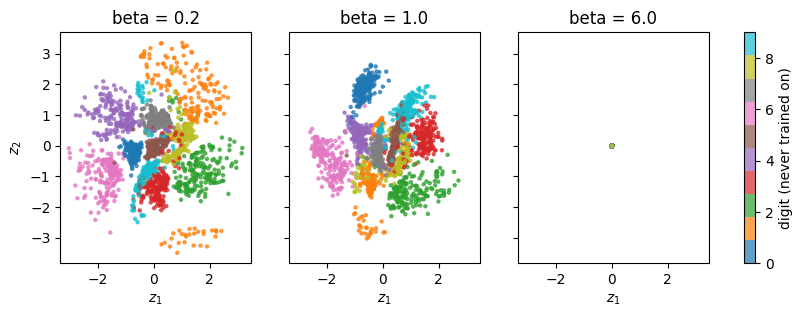

In [6]:
fig, axes = plt.subplots(1, len(betas), figsize=(9, 3), sharex=True, sharey=True)
for ax, beta in zip(axes, betas):
    codes = fits[beta][1]['codes']
    picture = ax.scatter(codes[:, 0], codes[:, 1], c=labels, cmap='tab10', s=5, alpha=0.7)
    ax.set(title=f'beta = {beta}', xlabel='$z_1$')
axes[0].set_ylabel('$z_2$')
fig.colorbar(picture, ax=axes, fraction=0.02, label='digit (never trained on)')
plt.show()